In [2]:
import pandas as pd
import numpy as np
from bursty_dynamics.scores import calculate_scores
from bursty_dynamics.trains import train_detection, train_info, train_scores
from bursty_dynamics.visual import *

### Questions to explore
- are target paragraphs longer?
- audio features different for target paragraphs?
- within paragraph: emotion before sentence?

In [3]:
paragraph_turns = pd.read_csv('../data/paragraph_turns.csv')

In [8]:
len(paragraph_turns)

263659

In [9]:
count_collective_action_0 = paragraph_turns[paragraph_turns['collectiveAction'] == 0].shape[0]
print(count_collective_action_0)

13606


In [10]:
collective_action_counts = paragraph_turns[paragraph_turns['collectiveAction'] == 0].groupby('episode_id').size()

In [11]:
count_at_least_3 = (collective_action_counts >= 3).sum()
print(count_at_least_3)

1678


### Length of paragraph turns

In [12]:
# Count the length of sentences in number of words
paragraph_turns['sentence_length'] = paragraph_turns['sentence'].apply(lambda x: len(str(x).split()))

In [13]:
sorted_paragraph_turns = paragraph_turns.sort_values(by='sentence_length', ascending=True)
sorted_paragraph_turns['sentence_length'].describe()

count    263659.000000
mean         70.040370
std         306.071134
min           1.000000
25%           7.000000
50%          17.000000
75%          42.000000
max       14640.000000
Name: sentence_length, dtype: float64

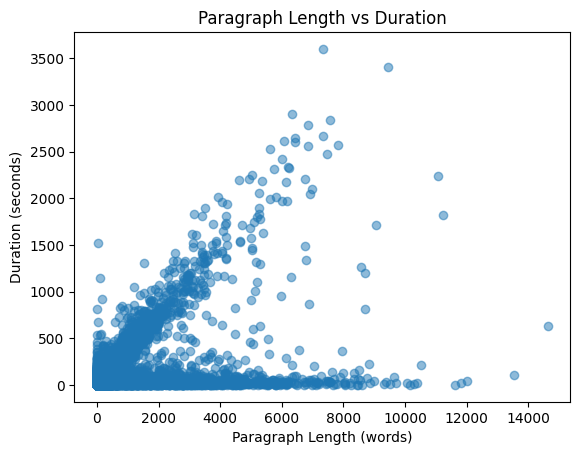

In [14]:
import matplotlib.pyplot as plt
plt.scatter(paragraph_turns['sentence_length'], paragraph_turns['duration'], alpha=0.5)
plt.title('Paragraph Length vs Duration')
plt.xlabel('Paragraph Length (words)')
plt.ylabel('Duration (seconds)')
plt.show()

### Burstiness

In [15]:
ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 0]

In [16]:
start_reference = pd.Timestamp("1970-01-01 00:00:00")

# Convert 'startTime' (which is in seconds) to proper datetime format
ca_paragraph_turns['startTime'] = start_reference + pd.to_timedelta(ca_paragraph_turns['startTime'], unit='s')

/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_23689/3042042419.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_paragraph_turns['startTime'] = start_reference + pd.to_timedelta(ca_paragraph_turns['startTime'], unit='s')


In [17]:
score_df = calculate_scores(ca_paragraph_turns, subject_id = 'episode_id', time_col = 'startTime')
score_df.tail()

/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/scores.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[time_col] = pd.to_datetime(df[time_col])


,episode_id,BP,MC
3588,10484,-14.695178,-0.364964
3589,10485,45.384454,0.320840
3590,10487,-0.566781,0.892225
3591,10488,-2.414214,NaN
3592,10490,-1.000000,NaN


In [18]:
num_nan_mc = score_df['BP'].isna().sum()
print(f"Number of NaN values in score_df['BP']: {num_nan_mc}")

Number of NaN values in score_df['BP']: 1325


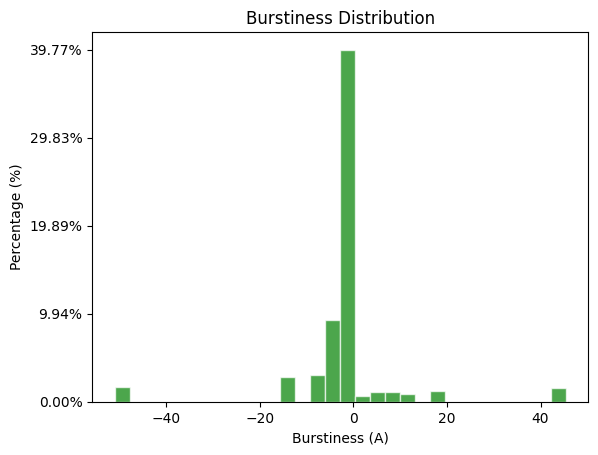

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the histogram values
values, bins, patches = plt.hist(score_df["BP"], bins=30, alpha=0.7, color="green", edgecolor='white')

# Calculate the total number of episodes
total_episodes = len(score_df["BP"])

# Convert counts to percentages
percentages = (values / total_episodes) * 100

# Get the current axis
ax = plt.gca()

# Set the y-axis ticks to the percentage values
ax.set_yticks(np.linspace(0, max(values), 5))
ax.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages), 5)])

# Add the title and axis labels
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (A)")
plt.ylabel("Percentage (%)")

# Show the plot
plt.show()

In [20]:
num_bp_greater_than_zero = (score_df["BP"] > 0).sum()
print(f"Number of entries in score_df['BP'] > 0: {num_bp_greater_than_zero}")

Number of entries in score_df['BP'] > 0: 383


In [23]:
train_df = train_detection(paragraph_turns, subject_id = 'episode_id', time_col = 'startTime', max_iet=30, time_unit='seconds')
train_df.tail()

/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/trains.py:280: RuntimeWarning: invalid value encountered in cast
  iet = (diff / np.timedelta64(1, 's')).astype(int).tolist()  # Convert to seconds
/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/trains.py:280: RuntimeWarning: invalid value encountered in cast
  iet = (diff / np.timedelta64(1, 's')).astype(int).tolist()  # Convert to seconds
/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/trains.py:280: RuntimeWarning: invalid value encountered in cast
  iet = (diff / np.timedelta64(1, 's')).astype(int).tolist()  # Convert to seconds
/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/trains.py:280: RuntimeWarning: invalid value encountered in cast
  iet = (diff / np.timedelta64(1, 's')).astype(int).tolist()  # Convert to seconds
/Users/theodoramoldovan/anaconda3/lib/python3.10/site-packages/bursty_dynamics/trains.py:280

,sentence,collectiveAction,racialJustice,collectiveActionMulti,episode_id,speaker,newSpeaker,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,...,F1frequency_sma3nzMean,startTime,endTime,duration,turnCount,pos,neg,compound,sentence_length,train_id
24011,And hopefully it does inspire or even reach ot...,1,0,NaN,10490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,0.0,0.0,0.0,28,1
24012,"- All right, thank you.",1,0,NaN,10490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,0.0,0.0,0.0,5,1
24013,"- For this week's music release radar, we're t...",1,1,NaN,10490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,0.0,0.0,0.0,20,1
24015,Many other artists took the time to stand by t...,1,0,NaN,10490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,0.0,0.0,0.0,15,1
24017,"(upbeat music) - Hey guys, this is DJ DaVinci ...",1,0,NaN,10490,NaN,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaN,0.0,0.0,0.0,25,1


### New metrics for all paragraph turns

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Sentiment (vader): Compound score > 0.05: Positive sentiment; Compound score < -0.05: Negative sentiment

In [5]:
analyzer = SentimentIntensityAnalyzer()
def analyze_sentiment(text):
    if isinstance(text, list):  # If text is a list, join into a single string
        text = " ".join(text)
    scores = analyzer.polarity_scores(text)
    return pd.Series([scores["pos"], scores["neg"], scores["compound"]])
paragraph_turns[["pos", "neg", "compound"]] = paragraph_turns["sentence"].apply(analyze_sentiment)

In [6]:
paragraph_turns['compound'].describe()

count    263659.000000
mean          0.088664
std           0.278967
min          -1.000000
25%           0.000000
50%           0.000000
75%           0.051600
max           1.000000
Name: compound, dtype: float64

In [7]:
paragraph_turns.to_csv('../data/paragraph_turns_sentiment.csv', index=False)

AngerBERT

MoralBERT: care/harm, fairness/cheating, loyalty/betrayal, authority/subversion, purity/degradation

In [35]:
bert_model = AutoModel.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [36]:
class MyModel(
    nn.Module,
    PyTorchModelHubMixin,
    # optionally, you can add metadata which gets pushed to the model card
    # repo_url="your-repo-url",
    pipeline_tag="text-classification",
    license="mit",
):
    def __init__(self, bert_model, moral_label=2):

        super(MyModel, self).__init__()
        self.bert = bert_model
        bert_dim = 768
        self.invariant_trans = nn.Linear(768, 768)
        self.moral_classification = nn.Sequential(nn.Linear(768,768),
                                                      nn.ReLU(),
                                                      nn.Linear(768, moral_label))

    def forward(self, input_ids, token_type_ids, attention_mask):
        pooled_output = self.bert(input_ids,
                                token_type_ids = token_type_ids,
                                attention_mask = attention_mask).last_hidden_state[:,0,:]


        pooled_output = self.invariant_trans(pooled_output)


        logits = self.moral_classification(pooled_output)

        return logits

In [37]:
def preprocessing(input_text, tokenizer):
    '''
    Returns <class transformers.tokenization_utils_base.BatchEncoding> with the following fields:
    - input_ids: list of token ids
    - token_type_ids: list of token type ids
    - attention_mask: list of indices (0,1) specifying which tokens should considered by the model (return_attention_mask = True).
    '''
    return tokenizer.encode_plus(
                        input_text,
                        add_special_tokens = True,
                        max_length = 150,
                        padding = 'max_length',
                        return_attention_mask = True,
                        return_token_type_ids = True,  # Add this line
                        return_tensors = 'pt',
                        truncation=True
                   )

In [ ]:
# # Define MFT values
# mft_values = ["care", "harm", "fairness", "cheating", "loyalty", "betrayal",
#               "authority", "subversion", "purity", "degradation"]

# # Function to load model, predict score, and return second value
# def get_model_score(sentence, mft):
#     repo_name = f"vjosap/moralBERT-predict-{mft}-in-text"

#     # Load the model
#     model = MyModel.from_pretrained(repo_name, bert_model=bert_model)

#     # Preprocess text
#     encodeds = preprocessing(sentence, tokenizer)

#     # Predict MFT score
#     output = model(**encodeds)
#     score = F.softmax(output, dim=1)

#     # Extract and return the second value from the tensor
#     return score[0, 1].item()

# # Apply function to each row in paragraph_turns
# def compute_mft_scores(sentence):
#     if isinstance(sentence, list):  # Join list into a single string if necessary
#         sentence = " ".join(sentence)

#     # Compute and return a dictionary of scores
#     return {mft: get_model_score(sentence, mft) for mft in mft_values}

# mft_scores_df = paragraph_turns["sentence"].apply(compute_mft_scores).apply(pd.Series)

# paragraph_turns = pd.concat([paragraph_turns, mft_scores_df], axis=1)

In [ ]:
# import pandas as pd
# import torch.nn.functional as F
# from joblib import Parallel, delayed
# from tqdm import tqdm
# import os

# # Define MFT values
# mft_values = ["care", "harm", "fairness", "cheating", "loyalty", "betrayal",
#               "authority", "subversion", "purity", "degradation"]

# # Load all models once (avoids reloading in every function call)
# models = {mft: MyModel.from_pretrained(f"vjosap/moralBERT-predict-{mft}-in-text", bert_model=bert_model) 
#           for mft in mft_values}

# # Function to compute MFT scores for a single sentence
# def compute_mft_scores(sentence, index, total):
#     if isinstance(sentence, list):
#         sentence = " ".join(sentence)

#     scores = {}
#     for mft, model in models.items():
#         encodeds = preprocessing(sentence, tokenizer)
#         output = model(**encodeds)
#         score = F.softmax(output, dim=1)
#         scores[mft] = score[0, 1].item()

#     # Print progress every 100 rows
#     if index % 100 == 0:
#         print(f"Processed {index}/{total} sentences ({(index/total)*100:.2f}%)")

#     return scores

# # Function to save progress periodically
# def save_progress(df, filename="../data/paragraph_turns_mft_progress.csv"):
#     df.to_csv(filename, index=False)
#     print(f"🔹 Saved progress to {filename}")

# # Get total number of sentences
# total_sentences = len(paragraph_turns)

# # Run computation in parallel with threading + progress bar
# num_threads = 8  # Adjust based on your system
# mft_scores_list = []
# batch_size = 500  # Save progress every 500 rows

# for i in tqdm(range(0, total_sentences, batch_size), desc="Processing Sentences"):
#     batch = paragraph_turns["sentence"].iloc[i:i + batch_size]
#     batch_results = Parallel(n_jobs=num_threads, backend="threading")(
#         delayed(compute_mft_scores)(sentence, idx, total_sentences) 
#         for idx, sentence in enumerate(batch)
#     )

#     # Append batch results
#     mft_scores_list.extend(batch_results)

#     # Convert to DataFrame & save progress
#     mft_scores_df = pd.DataFrame(mft_scores_list)
#     save_progress(mft_scores_df)

# # Merge final results with original DataFrame
# mft_scores_df = pd.DataFrame(mft_scores_list)
# paragraph_turns = pd.concat([paragraph_turns, mft_scores_df], axis=1)

# # Final save
# save_progress(paragraph_turns, filename="../data/paragraph_turns_mft.csv")
# print("Processing complete! Final results saved.")